# Logistic Regression from Scratch

## Objective
Implement binary Logistic Regression from scratch using NumPy.

To be implemented:
1. Sigmoid
2. Linear score
3. Predicted probabilities
4. Cost function
5. Gradients
6. One gradient-descent update
7. Complete gradient descent
8. Class prediction
9. Accuracy
10. Decision boundary

**Rules:** Use NumPy. Do not use `sklearn.linear_model.LogisticRegression`. Complete only cells marked **YOUR CODE HERE**.

## 1. Import Libraries

In [ ]:
%pip install numpy matplotlib scikit-learn

  Using cached scikit_learn-1.9.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp312-cp312-macosx_10_15_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 62.3 kB/s eta 0:00:0000:0200:11
   ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/9.5 MB 56.3 kB/s eta 0:02:25

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

ModuleNotFoundError: No module named 'numpy'

## 2. Load the Dataset

`X` contains two features and `y` contains binary class labels.

Inspect the shapes before continuing.

In [ ]:
X = np.array([
    [1.0, 1.0], [1.5, 1.2], [2.0, 1.8], [2.2, 2.0],
    [2.5, 2.3], [3.0, 2.8], [3.2, 3.0], [3.5, 3.2],
    [4.0, 3.8], [4.5, 4.0], [5.0, 4.5], [5.5, 5.0]
])

y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 2)
y shape: (12,)


## 3. Visualize the Dataset

Plot Class 0 and Class 1 using different markers or colours.

- Feature 1 → x-axis
- Feature 2 → y-axis

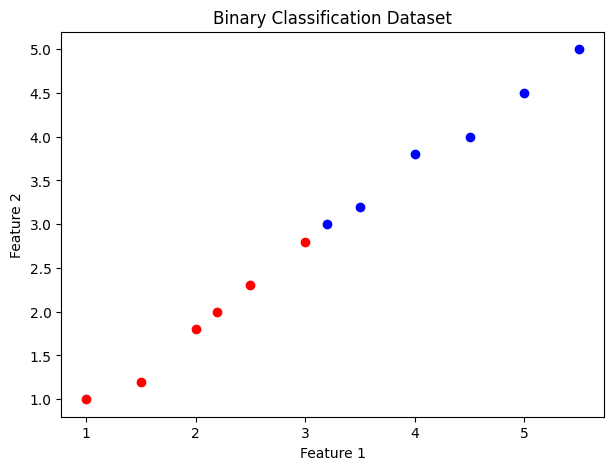

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(X[y == 0, 0], X[y == 0, 1], c="red")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="blue")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()

## 4. Logistic Regression Model

The model first calculates

$$
z = Xw+b
$$

and then

$$
\hat y = \sigma(z)
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

If `X.shape = (m,n)` and `w.shape = (n,)`, then `X @ w` has shape `(m,)`.

## 5. Step 1 — Implement Sigmoid

### Task
Complete `sigmoid(z)`.

Use `np.exp()`. Your function should work for both a scalar and a NumPy array.

In [ ]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
    pass

In [ ]:
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))

# Remember: sigmoid(0) should be 0.5

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


## 6. Step 2 — Compute the Linear Score

Implement

`z = X @ w + b`

### Hint
Use the `@` operator for matrix-vector multiplication.

In [ ]:
def compute_z(X, w, b):
    z = X @ w + b
    return z
    pass

In [ ]:
w = np.zeros(X.shape[1])
b = 0.0

z = compute_z(X, w, b)

print("z:", z)
print("z shape:", z.shape)

z: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
z shape: (12,)


## 7. Step 3 — Compute Predicted Probabilities

The predicted probability is

$$
\hat y = \sigma(Xw+b)
$$

### Task
Implement `predict_probability()` using the functions you have already written.

In [ ]:
def predict_probability(X, w, b):
    y_hat = sigmoid(X @ w + b)
    return y_hat
    pass

In [ ]:
probabilities = predict_probability(X, w, b)
print(probabilities)

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


## 8. Step 4 — Implement the Cost Function

For binary Logistic Regression,

$$
J =
-\frac{1}{m}\sum_{i=1}^{m}
\left[
y^{(i)}\log(\hat y^{(i)})
+
(1-y^{(i)})\log(1-\hat y^{(i)})
\right]
$$

Use `np.clip()` to avoid taking `log(0)`.

### Hint
```python
epsilon = 1e-15
probabilities = np.clip(probabilities, epsilon, 1-epsilon)
```

In [ ]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    epsilon = 1e-15
    y_hat=predict_probability(X,w,b)
    y_hat = np.clip(y_hat, epsilon, 1-epsilon)
    J = -np.mean(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))
    return J

In [ ]:
initial_cost = compute_cost(X, y, w, b)
print("Initial cost:", initial_cost)

# With w=0 and b=0, every probability is 0.5.

Initial cost: 0.6931471805599453


## 9. Step 5 — Compute the Gradients

The gradients are

$$
dw = \frac{1}{m}X^T(\hat y-y)
$$

$$
db = \frac{1}{m}\sum(\hat y-y)
$$

### Shape check

If

```text
X.shape = (m,n)
w.shape = (n,)
y.shape = (m,)
```

then

```text
X.T.shape = (n,m)
y_hat-y   = (m,)
dw        = (n,)
```

Do not use a loop over training examples. Rather, use broadcasting.

In [ ]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    y_hat=predict_probability(X,w,b)

    dw = 1/m * X.T @ (y_hat-y)
    db = 1/m * np.sum(y_hat-y)
    return dw, db

In [ ]:
dw, db = compute_gradients(X, y, w, b)
print(X.shape)
print("dw:", dw)
print("dw shape:", dw.shape)
print("db:", db)

(12, 2)
dw: [-0.5625     -0.51666667]
dw shape: (2,)
db: 0.0


## 10. Step 6 — Implement One Gradient-Descent Update

Use

$$
w := w - \alpha dw
$$

$$
b := b - \alpha db
$$

### Task
Compute the gradients, update `w` and `b`, and return them.

In [ ]:
def gradient_descent_step(X, y, w, b, learning_rate):
    dw, db = compute_gradients(X, y, w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    return w, b

## 11. Step 7 — Implement Complete Gradient Descent

For each iteration:
1. Compute probabilities.
2. Compute cost.
3. Compute gradients.
4. Update parameters.
5. Store the cost.

In [ ]:
def train_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):

    w = np.zeros(X.shape[1])
    b = 0.0

    cost_history = []

    for i in range(num_iterations):
        J = compute_cost(X,y,w,b)
        cost_history.append(J)
        w, b = gradient_descent_step(X, y, w, b,learning_rate)
        
    return w, b, cost_history

## 12. Train the Model

Use learning rate `0.1` and `1000` iterations.

In [ ]:
learning_rate = 0.1
num_iterations = 1000

w, b, cost_history = train_logistic_regression(
    X, y, learning_rate, num_iterations
)

print("Final weights:", w)
print("Final bias:", b)
print("Final cost:", cost_history[-1])

Final weights: [0.93237099 1.04970645]
Final bias: -5.656246822064308
Final cost: 0.208888172012582


## 13. Plot the Cost

Plot iteration number against cost.

### Expected observation
The cost should generally decrease during training.

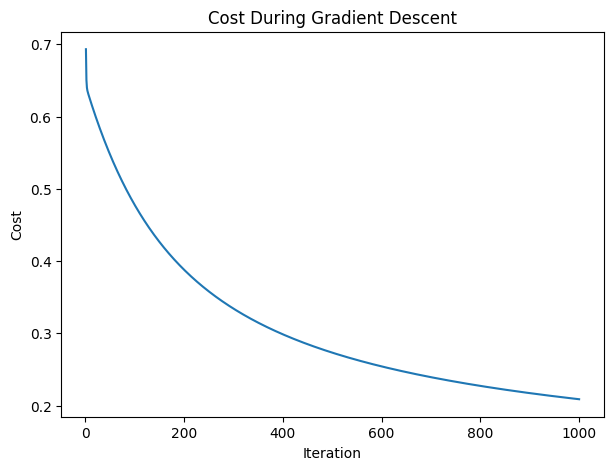

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(1, len(cost_history) + 1), cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")
plt.show()

## 14. Step 8 — Convert Probabilities into Class Predictions

Use the rule

$$
\hat y =
\begin{cases}
1 & \text{if probability} \geq 0.5\\
0 & \text{otherwise}
\end{cases}
$$

### Hint
```python
(probabilities >= threshold).astype(int)
```

In [ ]:
def predict(X, w, b, threshold=0.5):
    probabilities = predict_probability(X,w,b)
    return (probabilities >= threshold).astype(int)
    pass

In [ ]:
y_pred = predict(X, w, b)

print("Predictions:", y_pred)
print("Actual:     ", y)

Predictions: [0 0 0 0 0 1 1 1 1 1 1 1]
Actual:      [0 0 0 0 0 0 1 1 1 1 1 1]


## 15. Step 9 — Calculate Accuracy

$$
Accuracy =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

### Task
Implement `accuracy()` using NumPy.

In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_pred==y_true)
    pass

In [ ]:
print("Accuracy:", accuracy(y, y_pred))

Accuracy: 0.9166666666666666


## 16. Step 10 — Visualize the Decision Boundary

For two features, the decision boundary is

$$
w_1x_1+w_2x_2+b=0
$$

Therefore,

$$
x_2=-\frac{w_1x_1+b}{w_2}
$$

### Task
Plot the two classes and the learned decision boundary.

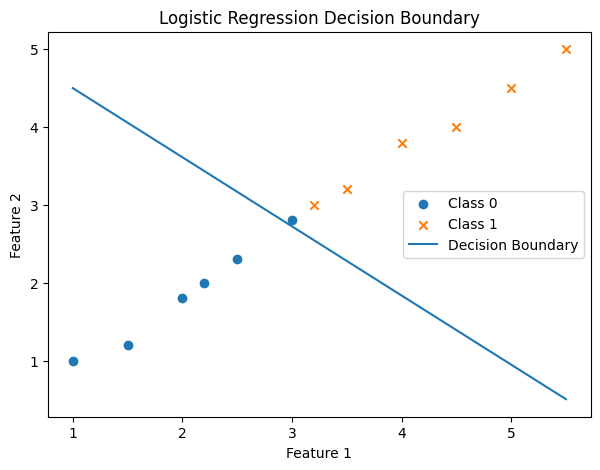

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', label='Class 1')

x1_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2_values = -(w[0] * x1_values + b) / w[1]

plt.plot(x1_values, x2_values, label='Decision Boundary')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.legend()
plt.show()

# Test your understanding — Learning Rate Experiment

Train the model using:

- `0.001`
- `0.1`
- `1.0`

Record the final cost and accuracy.

### Question
Which learning rate appears most appropriate for this dataset, and why?

In [ ]:
learning_rates = [0.001, 0.1, 1.0]

for i in learning_rates:
    w_i, b_i, costhist_i = train_logistic_regression(X, y, learning_rate=i, num_iterations=1000)
    y_pred_i = predict(X, w_i, b_i)

    print(f"Learning rate: {i}")
    print(f"Final cost: {costhist_i[-1]}")
    print(f"Accuracy: {accuracy(y, y_pred_i)}")


Learning rate: 0.001
Final cost: 0.6199321449891076
Accuracy: 0.5
Learning rate: 0.1
Final cost: 0.208888172012582
Accuracy: 0.9166666666666666
Learning rate: 1.0
Final cost: 0.10010793569421689
Accuracy: 1.0


# Test your understanding — Classification Threshold

Use thresholds:

- `0.3`
- `0.5`
- `0.7`

Compare the predictions and accuracy.

### Question
Why can changing the threshold change the classification result without changing the learned weights?

In [ ]:
thresholds = [0.3, 0.5, 0.7]

probabilities = predict_probability(X, w, b)

for i in thresholds:
    y_pred_threshold = predict(X, w, b, threshold=i)

    print(f"Threshold: {i}")
    print("Predictions:", y_pred_threshold)
    print(f"Accuracy: {accuracy(y, y_pred_threshold)}")
    print()

Threshold: 0.3
Predictions: [0 0 0 0 0 1 1 1 1 1 1 1]
Accuracy: 0.9166666666666666

Threshold: 0.5
Predictions: [0 0 0 0 0 1 1 1 1 1 1 1]
Accuracy: 0.9166666666666666

Threshold: 0.7
Predictions: [0 0 0 0 0 0 0 1 1 1 1 1]
Accuracy: 0.9166666666666666



**Important:** Use vectorized NumPy operations wherever possible instead of loops.

Using makeblobs()

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, n_features=2,centers=2,cluster_std=1.2,random_state=42)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 X values:\n", X[:5])
print("First 5 y values:", y[:5])

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', label='Class 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()
plt.show()

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))

# Remember: sigmoid(0) should be 0.5

In [ ]:
def compute_z(X, w, b):
    return X @ w + b
w = np.zeros(X.shape[1])
b = 0.0

z = compute_z(X, w, b)

print("z:", z)
print("z shape:", z.shape)

In [ ]:
def predict_probability(X, w, b):
    z = compute_z(X, w, b)
    return sigmoid(z)
probabilities = predict_probability(X, w, b)
print(probabilities)

In [ ]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    probabilities = predict_probability(X, w, b)

    epsilon = 1e-15
    probabilities = np.clip(probabilities, epsilon, 1 - epsilon)

    cost = -np.mean(
        y * np.log(probabilities) +
        (1 - y) * np.log(1 - probabilities)
    )

    return cost
initial_cost = compute_cost(X, y, w, b)
print("Initial cost:", initial_cost)

# With w=0 and b=0, every probability is 0.5.

In [ ]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]

    probabilities = predict_probability(X, w, b)
    error = probabilities - y

    dw = (X.T @ error) / m
    db = np.sum(error) / m

    return dw, db
dw, db = compute_gradients(X, y, w, b)

print("dw:", dw)
print("dw shape:", dw.shape)
print("db:", db)

In [ ]:
def gradient_descent_step(X, y, w, b, learning_rate):
    dw, db = compute_gradients(X, y, w, b)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    return w, b

In [ ]:
def train_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):

    w = np.zeros(X.shape[1])
    b = 0.0

    cost_history = []

    for i in range(num_iterations):

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        w, b = gradient_descent_step(
            X, y, w, b, learning_rate
        )

    return w, b, cost_history

In [ ]:
learning_rate = 0.1
num_iterations = 1000

w, b, cost_history = train_logistic_regression(
    X, y, learning_rate, num_iterations
)

print("Final weights:", w)
print("Final bias:", b)
print("Final cost:", cost_history[-1])

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(1, len(cost_history) + 1), cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")
plt.show()

In [ ]:
def predict(X, w, b, threshold=0.5):
    probabilities = predict_probability(X, w, b)
    return (probabilities >= threshold).astype(int)
y_pred = predict(X, w, b)

print("Predictions:", y_pred)
print("Actual:     ", y)

In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)
print("Accuracy:", accuracy(y, y_pred))

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', label='Class 1')

x1_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2_values = -(w[0] * x1_values + b) / w[1]

plt.plot(x1_values, x2_values, label='Decision Boundary')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Test your understanding — Learning Rate Experiment

Train the model using:

- `0.001`
- `0.1`
- `1.0`

Record the final cost and accuracy.

### Question
Which learning rate appears most appropriate for this dataset, and why?

In [ ]:

learning_rates = [0.001, 0.1, 1.0]

for lr in learning_rates:
    w_lr, b_lr, history_lr = train_logistic_regression(
        X, y, learning_rate=lr, num_iterations=1000
    )
    y_pred_lr = predict(X, w_lr, b_lr)

    print(f"Learning rate: {lr}")
    print(f"Final cost: {history_lr[-1]:.6f}")
    print(f"Accuracy: {accuracy(y, y_pred_lr):.4f}")
    print()


### Answer
For this dataset, a learning rate of **1.0** appears most appropriate among the three tested values. After 1000 iterations it gives the lowest final cost and the highest training accuracy. The learning rate 0.001 is too small and converges slowly, while 0.1 performs well but does not reach the same final fit within 1000 iterations.

# Test your understanding — Classification Threshold

Use thresholds:

- `0.3`
- `0.5`
- `0.7`

Compare the predictions and accuracy.

### Question
Why can changing the threshold change the classification result without changing the learned weights?

In [ ]:
thresholds = [0.3, 0.5, 0.7]

probabilities = predict_probability(X, w, b)

for threshold in thresholds:
    y_pred_threshold = predict(X, w, b, threshold=threshold)

    print(f"Threshold: {threshold}")
    print("Predictions:", y_pred_threshold)
    print(f"Accuracy: {accuracy(y, y_pred_threshold):.4f}")
    print()

### Answer
Changing the threshold changes how the same predicted probabilities are converted into class labels. The learned weights and bias do not change because they were obtained during training from the cost function and gradient descent. Only the final classification rule changes.
